In [1]:
%reload_ext autoreload
%autoreload 2

import numpy as np
import pickle

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter, NullLocator, NullFormatter
mpl.rc_file("../../nptf-test/production/matplotlibrc")

# SVI convergence

In [5]:
losses = pickle.load(open("../outputs/fits_cmp/svi_d22/losses.p", "rb"))
# losses = pickle.load(open("../outputs/production/fits/calibration-base23fix/svi_D23new_deltapsf_Mbase23fix_deltapsf/i0_n50000_ns10000_losses.p", "rb"))

In [6]:
def moving_average(losses, window):
    return np.convolve(losses, np.ones(window) / window, mode='valid')[:len(losses)]

def convergence_step(losses, window=100, eps=1e-4):
    smoothed = np.convolve(losses, np.ones(window) / window, mode='valid')
    for i in range(window, len(smoothed)):
        prev, curr = smoothed[i - window], smoothed[i]
        if abs((curr - prev) / prev) < eps:
            return i + window  # step in original losses array
    return -1

def convergence_step_2(losses, window=100, eps=1e-4):
    smoothed = np.convolve(losses, np.ones(window) / window, mode='valid')
    delta = smoothed[window:] - smoothed[:-window]
    rel = np.abs(delta / smoothed[:-window])
    idx = np.argmax(rel < eps)
    return int(idx + 2 * window) if rel[idx] < eps else -1

In [10]:
cs_s = []
for d in [10, 14, 18, 22]:
    losses = pickle.load(open(f"../outputs/fits_cmp/svi_d{d}/losses.p", "rb"))
    cs = convergence_step(losses, window=200, eps=1e-6)
    cs_s.append(cs)
    print(f"d={d}: convergence step = {cs}")

d=10: convergence step = 1043
d=14: convergence step = 1083
d=18: convergence step = 1685
d=22: convergence step = 1559


(100, 11552.960958653266)

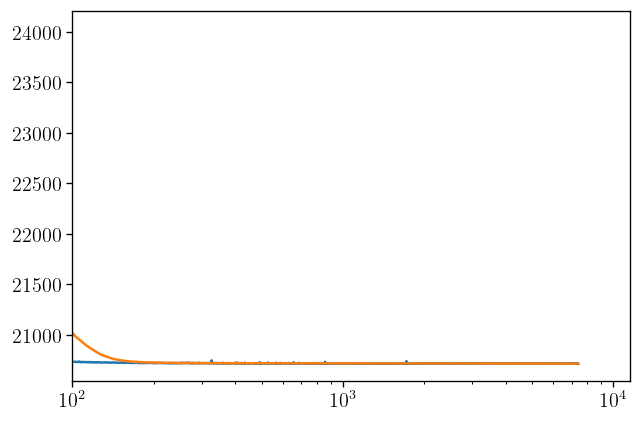

In [15]:
window = 100
plt.plot(losses[window:])
plt.plot(moving_average(losses, window))
# plt.yscale("log")
plt.xscale("log")
plt.xlim(window, None)
# plt.ylim(21400, 21750)

# Plotting

In [12]:
def get_fit_info(x, y):
     coeffs = np.polyfit(np.log(x), np.log(y), 1)
     fit_x = np.geomspace(x[0], x[-1], 100)
     fit_y = np.exp(np.polyval(coeffs, np.log(fit_x)))
     return coeffs, fit_x, fit_y

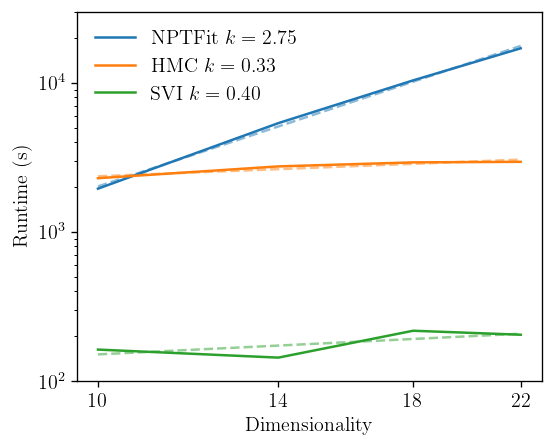

In [14]:
dim = [10, 14, 18, 22]
nptfit = [1953, 5370, 10384, 17035]
hmc = [2295, 2754, 2930, 2955]
svi = [163, 144, 218, 205]


fig, ax = plt.subplots(figsize=(5, 4))


coeffs_nptfit, fit_x, fit_y = get_fit_info(dim, nptfit)
ax.plot(fit_x, fit_y, '--', color='C0', alpha=0.5)

coeffs_hmc, fit_x, fit_y = get_fit_info(dim, hmc)
ax.plot(fit_x, fit_y, '--', color='C1', alpha=0.5)

coeffs_svi, fit_x, fit_y = get_fit_info(dim, svi)
ax.plot(fit_x, fit_y, '--', color='C2', alpha=0.5)

ax.plot(dim, nptfit, label=f"NPTFit $k={coeffs_nptfit[0]:.2f}$")
ax.plot(dim, hmc, label=f"HMC $k={coeffs_hmc[0]:.2f}$")
ax.plot(dim, svi, label=f"SVI $k={coeffs_svi[0]:.2f}$")


ax.set(xscale="log", yscale="log")
ax.set(xlabel="Dimensionality", ylabel="Runtime (s)")

ax.set(ylim=(1e2, 3e4))
ax.set_xticks(dim)
ax.xaxis.set_major_formatter(ScalarFormatter())
ax.ticklabel_format(style='plain', axis='x')
# ax.yaxis.set_major_formatter(ScalarFormatter())
# ax.ticklabel_format(style='plain', axis='y')
ax.xaxis.set_minor_locator(NullLocator())
ax.xaxis.set_minor_formatter(NullFormatter())
ax.legend(frameon=False, loc="upper left")